In [1]:
import matplotlib.pyplot as plt
import numpy as np
#%matplotlib widget
%matplotlib inline

$$
f_1(x,y)=x^2+y^2=7
\newline
f_2(x,y)=e^x+y=8
$$

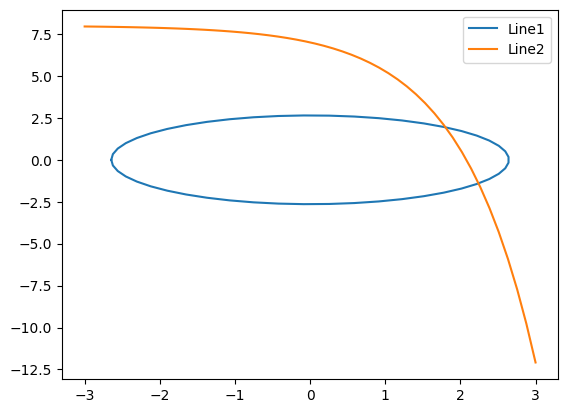

In [11]:
## 1st line
ths=np.linspace(-np.pi,np.pi)
r=np.sqrt(7)
x=np.cos(ths)*r
y=np.sin(ths)*r
plt.plot(x,y,label='Line1')
## 2nd line
x=np.linspace(-3,3)
y=8-np.exp(x)
plt.plot(x,y,label='Line2')
plt.legend()
#plt.gca().set_aspect('equal')

In [54]:
def show(A,fmt='%+7.2f'):
    """
    Function to more neatly print out the matrix.
    """
    print('--')
    for i, As in enumerate(A):
        cr=''
        for j, a in enumerate(As):
            cr=f'{cr} {fmt}'%a
        print(cr)

import numpy as np


def gauss(A):
    # swap and forward
    for icol in range(0,A.shape[0]-1):
        ## swap
        a=np.abs(A[icol:,icol])
        ind=np.argsort(a)
        ind=ind[::-1] # reverse order
        A[icol:,:]=A[icol:,:][ind,:]

        ## forward
        for irow in range(icol+1,A.shape[0]):
            A[irow,:]=A[irow,:]-A[irow,icol]/A[icol,icol]*A[icol,:]
    # now one could 'diagonalize'
    for icol in range(A.shape[0]-1,0,-1):
        for irow in range(0,icol):
            f=A[irow,icol]/A[icol,icol]
            A[irow,:]=A[irow,:]-f*A[icol,:]
    for icol in range(A.shape[0]):
        A[icol,:]=A[icol,:]/A[icol,icol]

    return A[:,-1]



# initial empty A.
A=np.zeros((3,4))
# filling up the matrix.
A[0,:]=2,3,3,9
A[1,:]=1,-1,1,1
A[2,:]=3,11,5,35
gauss(A)

array([ 21. ,   4.5, -15.5])

(2, 2)
A.shape: (2, 3)
dx: [-0.88572367 -2.23927633]
(2, 2)
A.shape: (2, 3)
dx: [-0.70516948 -0.39946065]
(2, 2)
A.shape: (2, 3)
dx: [-0.45369965  0.56168023]
(2, 2)
A.shape: (2, 3)
dx: [-0.14118955  0.00801846]
(2, 2)
A.shape: (2, 3)
dx: [-0.01194151  0.00604109]


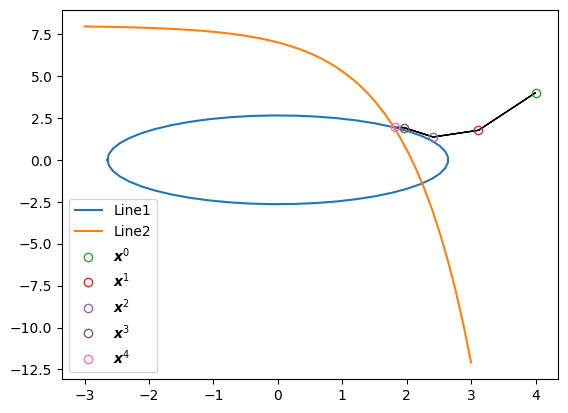

In [ ]:
## 1st line
ths=np.linspace(-np.pi,np.pi)
r=np.sqrt(7)
x=np.cos(ths)*r
y=np.sin(ths)*r
plt.plot(x,y,label='Line1')
## 2nd line
x=np.linspace(-3,3)
y=8-np.exp(x)
plt.plot(x,y,label='Line2')
plt.legend()
#plt.gca().set_aspect('equal')



def func(x1,x2):
    f=np.zeros(2) #
    f[0]=x1**2+x2**2-7
    f[1]=np.exp(x1)+x2-8
    return f

def jacob(x1,x2):
    j=np.zeros((2,2)) # 2x2 jacob
    j[0,0]=2*x1
    j[0,1]=2*x2
    j[1,0]=np.exp(x1)
    j[1,1]=1
    return j

x=np.zeros(2) ## initial guess
x[::]=4 ## initial guess

for n in range(5):
    plt.plot(*x,'o',mfc='None',label=r'$\boldsymbol{x}^{%i}$'%n)
    J=jacob(*x)
    print(J.shape)
    F=func(*x)

    ## augmented matrix
    A=np.zeros((J.shape[0],J.shape[0]+1))
    A[:2,:2]=J[:,:]
    A[:,-1]=-F[::]
    print(f'A.shape: {A.shape}')
    dx=gauss(A)
    print(f'dx: {dx}')
    plt.arrow(*x,*dx)
    x=x+dx


plt.legend()
## guass elimination
